In [1]:
import pandas as pd
from joblib import load
from sklearn.model_selection import cross_val_predict


model = load("../models_raw/GBC500.joblib")
dataset_test = pd.read_csv("../data/matches500test.csv")
data_test = dataset_test.drop(columns=["winning_team"])
target_test = dataset_test["winning_team"]

cv_untuned= cross_val_predict(
    model,
    data_test,
    target_test,
    cv = 10
)

cv_untuned_results = pd.DataFrame(cv_untuned)
display(cv_untuned_results)

,0
0,Team1
1,Team1
2,Team1
3,Team1
4,Team1
...,...
164,Team1
165,Team1
166,Team1
167,Team0


Let's try making graph accuracies on all time stamps

In [13]:
from pathlib import Path

accuracies = []
data_filenames = sorted([f.name for f in Path("../data/").glob("matches*test.csv")], key = lambda file : int(file[7:-8]))
model_filenames = sorted([f.name for f in Path("../models_raw/").glob("GBC*.joblib")], key = lambda file : int(file[4:-7]))
time_stamps = [f[7:-8] for f in data_filenames]
display(data_filenames)

for i in range(len(data_filenames)):

    dataset_test = pd.read_csv("../data/" + data_filenames[i])
    data_test = dataset_test.drop(columns=["winning_team", "match_id"])
    target_test = dataset_test["winning_team"]

    model = load("../models_raw/" + model_filenames[i])
    

    predictions = model.predict(data_test)
    accuracy = (predictions==target_test).mean()

    accuracies.append(accuracy)

accuracies_df = pd.DataFrame({"Accuracy" : accuracies, "Time stamps in seconds" : time_stamps})
accuracies_df

['matches500test.csv', 'matches1000test.csv', 'matches1500test.csv']

,Accuracy,Time stamps in seconds
0,0.479290,500
1,0.609467,1000
2,0.704142,1500


Text(0.5, 1.0, 'Untuned model across all time stamps')

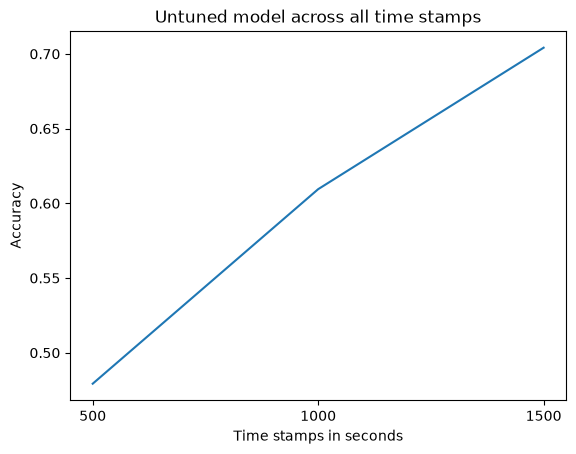

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(accuracies_df, x="Time stamps in seconds", y="Accuracy")
plt.title("Untuned model across all time stamps")